In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math


C:\Users\pc\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Load data
df = pd.read_csv("monthly_milk_production.csv")

# Display first rows
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
# Check shape and info
print(df.shape)
df.info()

(168, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
# Check missing values
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [5]:
# Automatically detect the date column
date_col = None
for col in df.columns:
    if "month" in col.lower() or "date" in col.lower() or "time" in col.lower():
        date_col = col
        break

print("Detected date column:", date_col)

Detected date column: Date


In [6]:
# Convert date column
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

In [7]:
# Detect numeric column
value_col = df.select_dtypes(include=['float64','int64']).columns[0]

print("Detected numeric column:", value_col)


Detected numeric column: Production


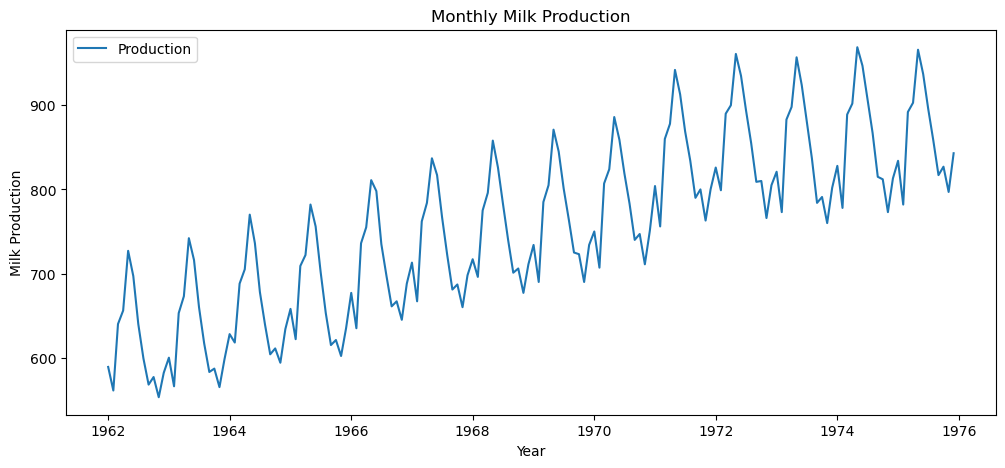

In [8]:
# Plot cleaned series
plt.figure(figsize=(12,5))
plt.plot(df[value_col], label=value_col)
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [9]:
# 2. Data preparation and Deep Learning

In [10]:
# Normalize Data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[[value_col]])

In [11]:
# Create Sequences
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled_data, window)

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [13]:
# Train-Test Split
train_size = int(len(X) * 0.80)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train.shape, X_test.shape

((124, 12, 1), (32, 12, 1))

In [14]:
# 3.Build RNN , LSTM , GRU Models

In [15]:
# RNN Model
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

C:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_rnn = rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0502 - val_loss: 0.0700
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0128 - val_loss: 0.0097
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0076 - val_loss: 0.0237
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0077 - val_loss: 0.0059
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0051 - val_loss: 0.0087
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0045 - val_loss: 0.0089
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0037 - val_loss: 0.0067
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0025 - val_loss: 0.0049
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0022 - val_loss: 0.0041
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0021 - val_loss: 0.0042
E

In [17]:
# LSTM Model
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

C:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.2095 - val_loss: 0.3046
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0725 - val_loss: 0.0522
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0361 - val_loss: 0.0473
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0333 - val_loss: 0.0304
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0272 - val_loss: 0.0493
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0285 - val_loss: 0.0406
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0266 - val_loss: 0.0281
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0257 - val_loss: 0.0280
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0255 - val_loss: 0.0312
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0250 - val_loss: 0.0305
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0246 - val_loss: 0.0266
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0242 - val_loss: 0.0278
E

In [19]:
# GRU Model

In [20]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

C:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_gru = gru_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.1463 - val_loss: 0.1826
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0401 - val_loss: 0.0292
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0334 - val_loss: 0.0237
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0290 - val_loss: 0.0363
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0241 - val_loss: 0.0485
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0245 - val_loss: 0.0423
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0230 - val_loss: 0.0319
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0222 - val_loss: 0.0294
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0217 - val_loss: 0.0293
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0210 - val_loss: 0.0297
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0206 - val_loss: 0.0316
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0204 - val_loss: 0.0268
E

In [22]:
# 4. Evaluation and Prediction

In [23]:

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)
    actual = scaler.inverse_transform(y_test)
    
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    return rmse, mae, pred

In [24]:
### RNN Evaluation
rnn_rmse, rnn_mae, rnn_pred = evaluate(rnn_model, X_test, y_test)
rnn_rmse, rnn_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


(18.538824645326002, 14.37455940246581)

In [25]:
### LSTM Evaluation
lstm_rmse, lstm_mae, lstm_pred = evaluate(lstm_model, X_test, y_test)
lstm_rmse, lstm_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


(31.018171009375617, 25.76827812194823)

In [26]:
### GRU Evaluation
gru_rmse, gru_mae, gru_pred = evaluate(gru_model, X_test, y_test)
gru_rmse, gru_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


(30.520651265609725, 24.362520217895497)

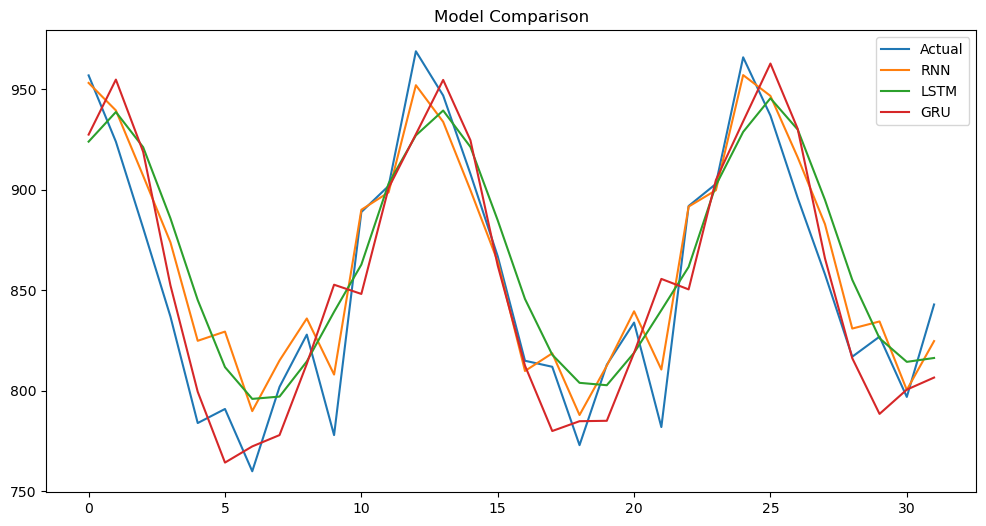

In [27]:
### Plot Predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test), label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [28]:
# 5. ForeCast next 12 months

In [29]:
def forecast_next(model, last_seq, steps=12):
    result = []
    seq = last_seq.copy()

    for _ in range(steps):
        pred = model.predict(seq.reshape(1,window,1))[0]
        result.append(pred)
        seq = np.append(seq[1:], pred).reshape(window,1)
    return np.array(result)

In [30]:
last_seq = scaled_data[-window:]
future = forecast_next(lstm_model, last_seq, 12)
future = scaler.inverse_transform(future)
future

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[834.6408 ],
       [847.933  ],
       [883.1169 ],
       [906.8093 ],
       [927.4487 ],
       [926.7312 ],
       [912.8904 ],
       [891.6761 ],
       [869.79156],
       [857.15656],
       [846.01324],
       [849.68536]], dtype=float32)

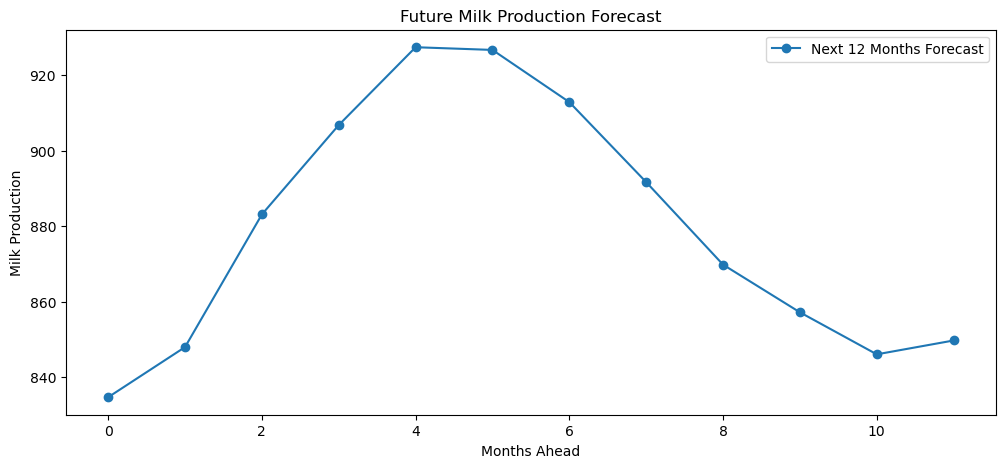

In [31]:
#### Plot Forecast
plt.figure(figsize=(12,5))
plt.plot(future, marker='o', label='Next 12 Months Forecast')
plt.title("Future Milk Production Forecast")
plt.xlabel("Months Ahead")
plt.ylabel("Milk Production")
plt.legend()
plt.show()